# Foundation/Housekeeping

Importing Relevant Libraries/Tools

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Data Cleaning

Creating DataFrame and Initial Clean Up

In [21]:
# ensuring excel file is not corrupt

xls = pd.ExcelFile("fixed_excel.xlsx")
print(xls.sheet_names)

['Sheet1']


In [22]:
# creating dataframe
df = pd.read_excel(r"fixed_excel.xlsx") # reads data directly from Excel so the notebook always uses the latest saved version

# standardizing lowercase headers for convenience
df.columns = df.columns.str.lower() # lowercase all headers

# anonomyzing companies
company_dict = {company: f"C{idx:03d}" for idx, company in enumerate(df["company"].unique())} # creating unique id for each company and storing in a dictionary

df["company_id"] = df["company"].map(company_dict) # mapping new ids to company names

df = df.drop(columns=["company"]) # removing original column with real company names

# checking df anonymized dataframe
# df

# Data Cleaning

In [23]:
# checking basic data info: types, total entries, etc...
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   major                       27 non-null     object        
 1   application date            26 non-null     datetime64[ns]
 2   result date                 0 non-null      float64       
 3   role                        27 non-null     object        
 4   resume                      27 non-null     object        
 5   transcript                  27 non-null     object        
 6   cover letter                27 non-null     object        
 7   ghosted                     5 non-null      object        
 8   round 1                     3 non-null      object        
 9   round 2                     1 non-null      object        
 10  round 3                     0 non-null      float64       
 11  declined                    1 non-null      object        
 

In [24]:
# ensuring type datetime objects are not altered; result dates will eventually become datetime objects as I hear back from employers
columns_lower = [lower for lower in df.columns if lower not in ["application date", "result date"]] # only capturing columns that are not date columns

# altering all columns except "date" to lowercase strings for ease of use and consistency
df[columns_lower] = df[columns_lower].astype(str).apply(lambda x: x.str.lower())

# replacing "nan" strings with to the value 0; will convert "yes" and "no" to binary eventually
df[columns_lower] = df[columns_lower].replace({"nan":0})

# checking types are consistent with the transformation
df.info()

# checking new dataframe
df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   major                       27 non-null     object        
 1   application date            26 non-null     datetime64[ns]
 2   result date                 0 non-null      float64       
 3   role                        27 non-null     object        
 4   resume                      27 non-null     object        
 5   transcript                  27 non-null     object        
 6   cover letter                27 non-null     object        
 7   ghosted                     27 non-null     object        
 8   round 1                     27 non-null     object        
 9   round 2                     27 non-null     object        
 10  round 3                     27 non-null     int64         
 11  declined                    27 non-null     object        
 

/var/folders/66/0pgksbln22l1cf4c79r9bnr00000gn/T/ipykernel_50912/2342308958.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[columns_lower] = df[columns_lower].replace({"nan":0})


,major,application date,result date,role,resume,transcript,cover letter,ghosted,round 1,round 2,...,platform,reached out?,country,attendance,hourly rate,salary,industry,meet qualifications,year,company_id
0,data science,2026-02-04,NaN,data management intern,yes,no,yes,yes,0,0,...,handshake,0,united states,remote/hybrid/in person,20,0,business,yes,junnior,c000
1,igs,2026-04-26,NaN,researcher,yes,no,yes,no,yes,no,...,handshake,0,united states,remote/hybrid/in person,0,0,non-profit,yes,junnior,c001
2,data science,2026-04-26,NaN,data analyst intern,yes,no,no,yes,0,0,...,employer website,0,united states,remote,$17-$21.50,0,manufacturing,yes,junnior,c002
3,data science,2026-04-27,NaN,data analyst intern,yes,no,yes,yes,0,0,...,employer website,0,united states,remote,$15-$20,0,"journalism, media, and publishing",yes,junnior,c003
4,data science,2026-04-27,NaN,data analyst intern,yes,no,no,no,no,0,...,employer website,0,united states,remote/hybrid/in person,25,0,transportation and logistics,yes,junnior,c004


# Creating Basic Plots

                                      role  total
2                      data analyst intern      8
6                      data science intern      4
12             software engineering intern      3
1                             data analyst      2
10                              researcher      2
0   ai/machine learning engineering intern      1
3                           data engineeer      1
4                   data management intern      1
5                 data science and analyst      1
7   e-commerce growth and marketing intern      1
8              learning data and analytics      1
9                        operations intern      1
11        sales technical analytics intern      1


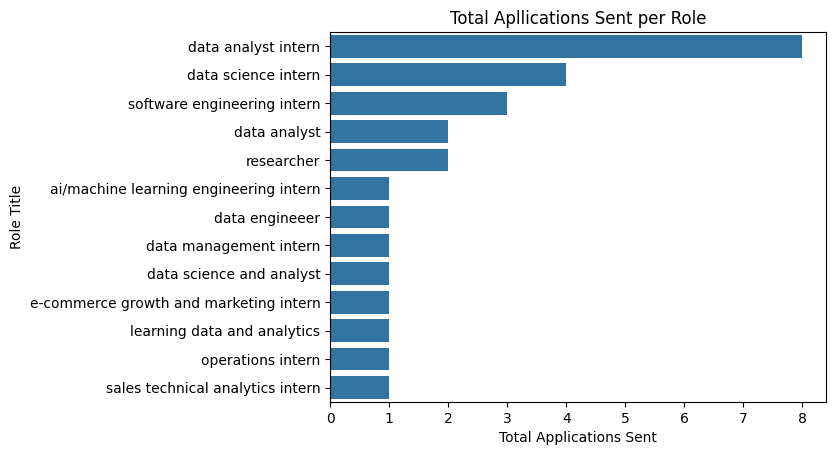

In [72]:
# creating DataFrameGroupBy object to keep count of number of applications per role
grouped_role = df.groupby("role").size().reset_index(name = "total").sort_values(by = "total", ascending = False) # grouping data based on role title, using size to keep count, reseting index to return Series object produced by size into DataFrame, and sorting values in descending order

# print text running totals
print(grouped_role)

# basic bar plot visualization of counts
sns.barplot(data = grouped_role, x = "total", y = "role")

# adjusting aesthetics: titles
plt.title("Total Apllications Sent per Role")
plt.xlabel("Total Applications Sent")
plt.ylabel("Role Title")

plt.show()

In [ ]:
# grouping all "data" related roles under one group
import re

# creating regex and will parse through str in "role" column in order to match
regex_data = r"data"

for roles in grouped_role["role"]:

    # stripping whitespace and splitting on spaces
    strip_str = roles.strip()

    # finding matches
    match = re.findall(regex_data, strip_str, flags = re.IGNORECASE)

    if match:

        grouped_role["role"] = grouped_role["role"].replace(role, "data umbrella")

    else:

        continue

grouped_role









        

# grouped_role["data umbrella"] = [data for data in grouped_role["data"] if  ]
# filter through role str and find "data"

# if match then create running total

# create new umbrella term
# grouped_role["data_science_or_analysty"] = grouped_role["data_science_or_analysty"]

,role,total
2,data analyst intern,8
6,data umbrella,4
12,software engineering intern,3
1,data analyst,2
10,researcher,2
0,ai/machine learning engineering intern,1
3,data engineeer,1
4,data management intern,1
5,data science and analyst,1
7,e-commerce growth and marketing intern,1


Same Data but Visualized Through Pie Chart

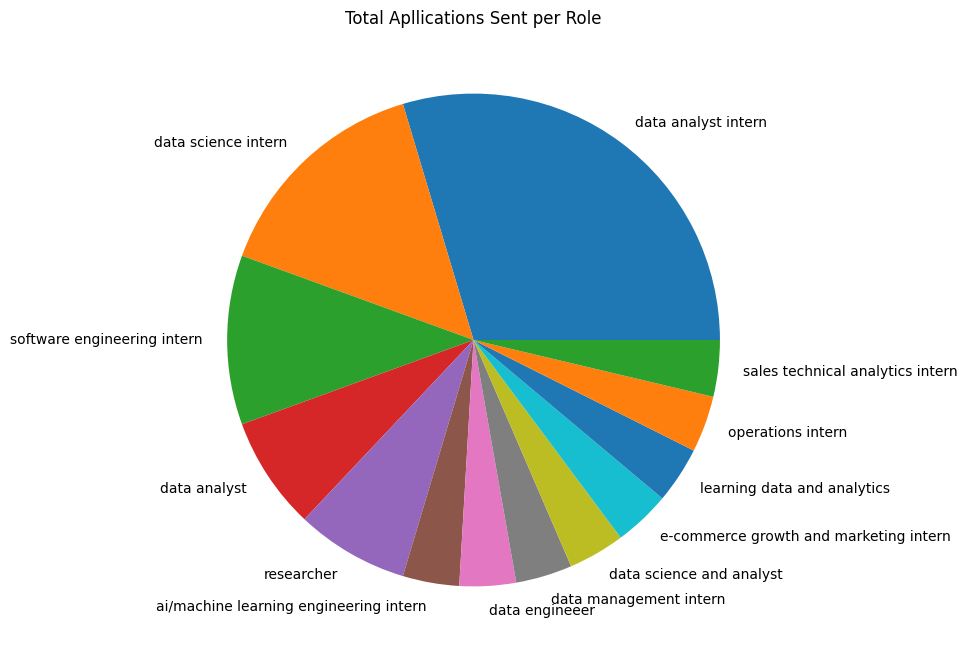

In [26]:
# aesthetic adjustments: size, plot title, etc...
plt.figure(figsize = (8,8))
plt.title("Total Apllications Sent per Role")

# creating pie chart
plt.pie(grouped_role["total"], labels = grouped_role["role"]);

plt.show()

# Future Questions
- Is there any relation between accesibility and communication with recruiters in terms of application advancement?
- Do the presence of additional documents (cover letter, transcript, etc) lead to trends in application advancement?
- 